In [1]:
# Importing libraries
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
df = pd.read_csv(
    "OnlineRetail.csv",
    encoding='ISO-8859-1'
)

# Display first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
# Shape of dataset
print("Shape of Dataset:")
print(df.shape)

print("\n")

# Information about dataset
print("Dataset Information:")
print(df.info())

print("\n")

# Missing values
print("Missing Values:")
print(df.isnull().sum())

Shape of Dataset:
(541909, 8)


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [4]:
# Remove rows where CustomerID is missing
df = df.dropna(subset=['CustomerID'])

print("After removing missing CustomerID:")
print(df.shape)

After removing missing CustomerID:
(406829, 8)


In [5]:
# Remove duplicate records
df = df.drop_duplicates()

print("After removing duplicates:")
print(df.shape)

After removing duplicates:
(401604, 8)


In [6]:
# Remove cancelled invoices
df = df[
    ~df['InvoiceNo']
    .astype(str)
    .str.startswith('C')
]

print("After removing cancelled orders:")
print(df.shape)

After removing cancelled orders:
(392732, 8)


In [7]:
# Keep only positive quantities
df = df[df['Quantity'] > 0]

print("After removing negative quantities:")
print(df.shape)

After removing negative quantities:
(392732, 8)


In [8]:
# Keep only positive prices
df = df[df['UnitPrice'] > 0]

print("After removing invalid prices:")
print(df.shape)

After removing invalid prices:
(392692, 8)


In [9]:
# Convert InvoiceDate into datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Check datatype
print(df['InvoiceDate'].dtype)

datetime64[ns]


In [10]:
# Total amount spent per transaction
df['TotalPrice'] = (
    df['Quantity'] *
    df['UnitPrice']
)

# Display sample
df[['Quantity', 'UnitPrice', 'TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


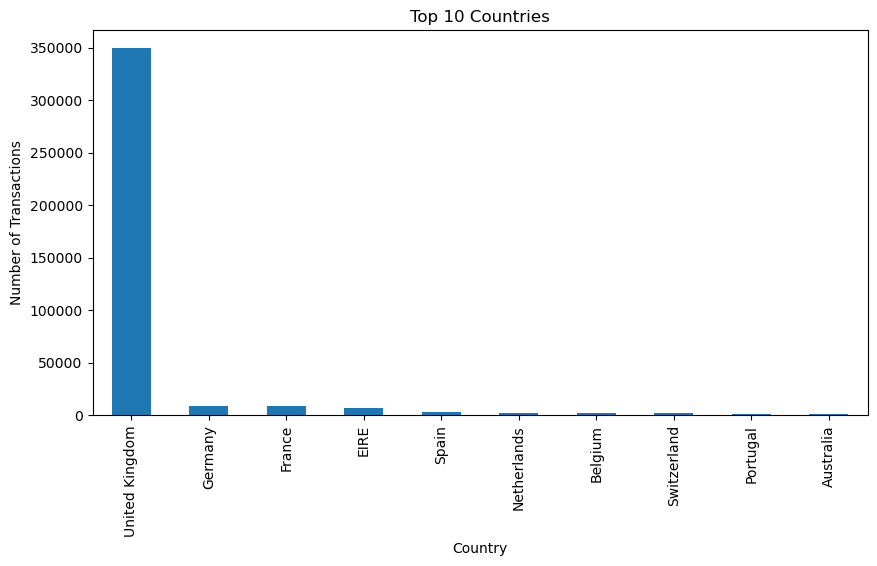

In [11]:
# Count top countries
top_countries = (
    df['Country']
    .value_counts()
    .head(10)
)

# Plot
plt.figure(figsize=(10,5))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")

plt.show()

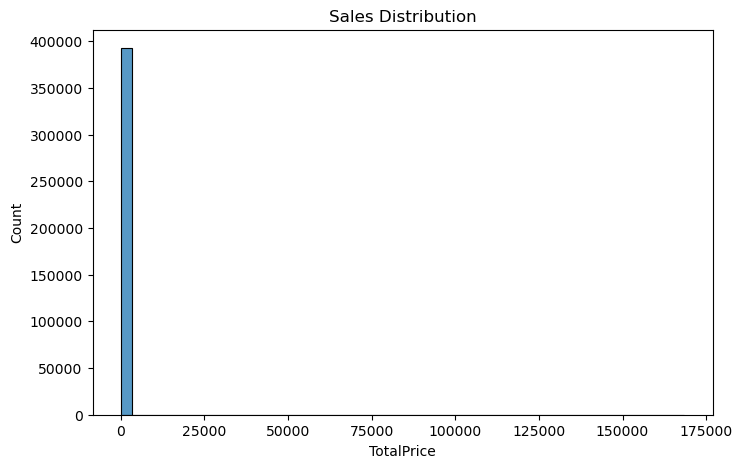

In [12]:
# Plot sales distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['TotalPrice'],
    bins=50
)

plt.title("Sales Distribution")

plt.show()

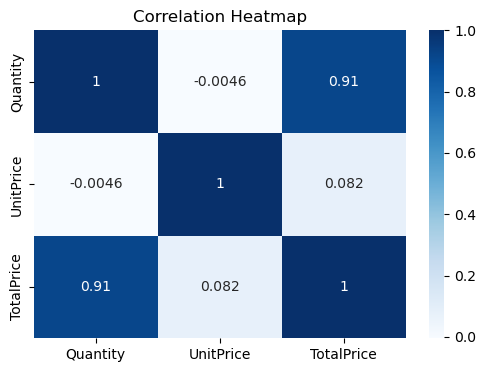

In [13]:
# Select numeric columns
corr = df[
    ['Quantity', 'UnitPrice', 'TotalPrice']
].corr()

# Plot heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

In [14]:
# Latest date in dataset + 1 day
snapshot_date = (
    df['InvoiceDate'].max() +
    pd.Timedelta(days=1)
)

print(snapshot_date)

2011-12-10 12:50:00


In [15]:
# Create RFM table
rfm = df.groupby('CustomerID').agg({

    # Recency
    'InvoiceDate': lambda x:
        (snapshot_date - x.max()).days,

    # Frequency
    'InvoiceNo': 'nunique',

    # Monetary
    'TotalPrice': 'sum'

})

# Rename columns
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

# Display first rows
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


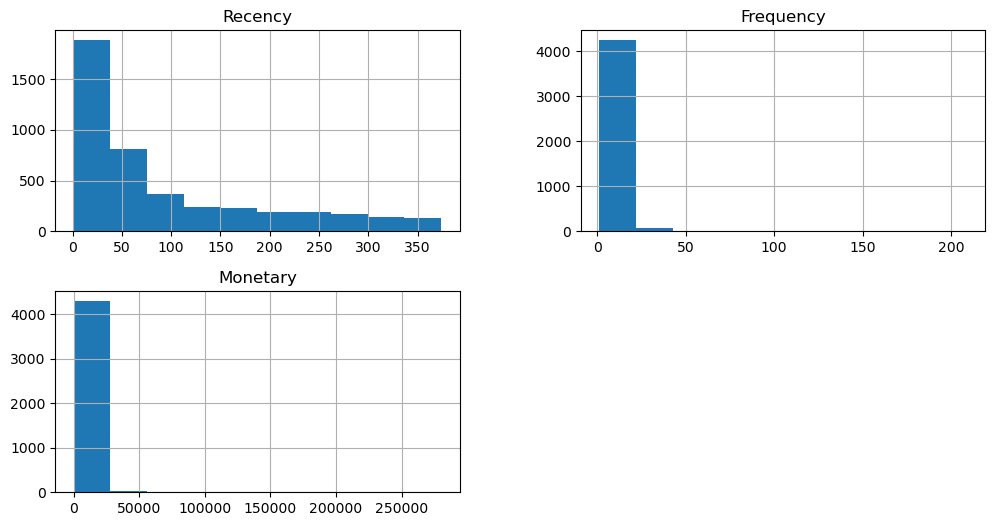

In [16]:
# Plot RFM distributions
rfm.hist(
    figsize=(12,6)
)

plt.show()

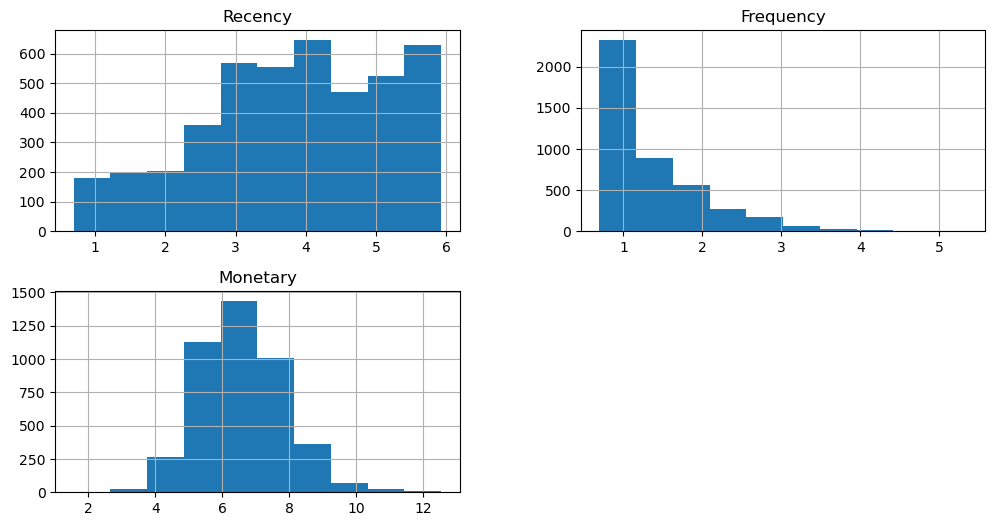

In [17]:
# Apply log transformation
rfm_log = np.log1p(rfm)

# Check transformed distributions
rfm_log.hist(
    figsize=(12,6)
)

plt.show()

In [18]:
# Calculate Q1 and Q3
Q1 = rfm_log.quantile(0.25)
Q3 = rfm_log.quantile(0.75)

# Interquartile Range
IQR = Q3 - Q1

# Remove outliers
rfm_log = rfm_log[
    ~(
        (rfm_log < (Q1 - 1.5 * IQR)) |
        (rfm_log > (Q3 + 1.5 * IQR))
    ).any(axis=1)
]

print(rfm_log.shape)

(4265, 3)


In [19]:
# Initialize scaler
scaler = StandardScaler()

# Scale features
rfm_scaled = scaler.fit_transform(
    rfm_log
)

print(rfm_scaled.shape)

(4265, 3)


In [20]:
# Empty list
wcss = []

# Try K values from 1 to 10
for k in range(1,11):

    # Create model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    # Fit model
    kmeans.fit(rfm_scaled)

    # Store inertia
    wcss.append(
        kmeans.inertia_
    )

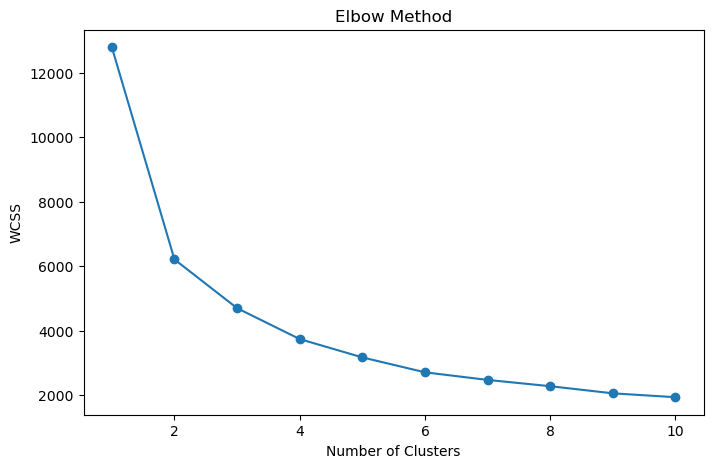

In [21]:
# Plot elbow curve
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [22]:
# Check silhouette scores
for k in range(2,11):

    # Create model
    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    # Predict clusters
    labels = model.fit_predict(
        rfm_scaled
    )

    # Calculate score
    score = silhouette_score(
        rfm_scaled,
        labels
    )

    print(
        "K =", k,
        "Score =", score
    )

K = 2 Score = 0.43390096597656297
K = 3 Score = 0.32640369868532676
K = 4 Score = 0.33345463312835627
K = 5 Score = 0.30938567148649265
K = 6 Score = 0.3113773452520991
K = 7 Score = 0.27849950928389333
K = 8 Score = 0.2718435628833574
K = 9 Score = 0.2810231707083087
K = 10 Score = 0.2744564057997734


In [23]:
# Final KMeans model
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

# Predict clusters
clusters = kmeans.fit_predict(
    rfm_scaled
)

# Add cluster column
rfm_log['Cluster'] = clusters

# Display sample
rfm_log.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347.0,1.098612,2.079442,8.368925,1
12348.0,4.330733,1.609438,7.494564,3
12349.0,2.995732,0.693147,7.472245,0
12350.0,5.739793,0.693147,5.815324,2
12352.0,3.610918,2.197225,7.826858,1


In [24]:
# Count customers in each cluster
print(
    rfm_log['Cluster']
    .value_counts()
)

Cluster
2    1433
3    1177
0     839
1     816
Name: count, dtype: int64


In [25]:
# Average values of each cluster
cluster_profile = (
    rfm_log
    .groupby('Cluster')
    .mean()
)

print(cluster_profile)

          Recency  Frequency  Monetary
Cluster                               
0        2.904406   0.995133  5.899390
1        2.296280   2.281526  8.050284
2        5.131311   0.804655  5.577058
3        4.062772   1.498778  7.141143


In [26]:
# Apply PCA
pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    rfm_scaled
)

In [27]:
# Create dataframe
pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1', 'PC2']
)

# Add cluster labels
pca_df['Cluster'] = clusters

# Display sample
pca_df.head()

,PC1,PC2,Cluster
0,2.750014,-0.750411,1
1,0.594795,0.798090,3
2,0.193072,-0.450237,0
3,-1.713707,0.672176,2
4,1.621802,0.706640,1


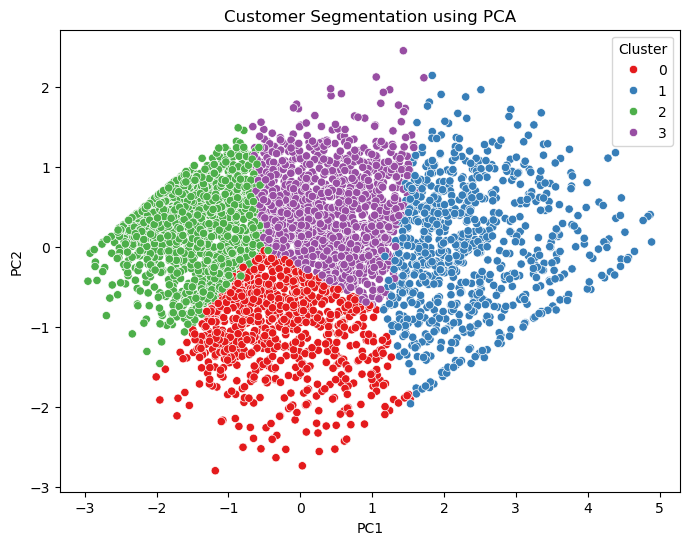

In [28]:
# Plot clusters
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title("Customer Segmentation using PCA")

plt.show()

In [29]:
# Create DBSCAN model
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

# Predict clusters
db_labels = dbscan.fit_predict(
    rfm_scaled
)

# Add labels
rfm_log['DBSCAN_Cluster'] = db_labels

# Count labels
print(
    rfm_log['DBSCAN_Cluster']
    .value_counts()
)

DBSCAN_Cluster
 0    4262
-1       3
Name: count, dtype: int64


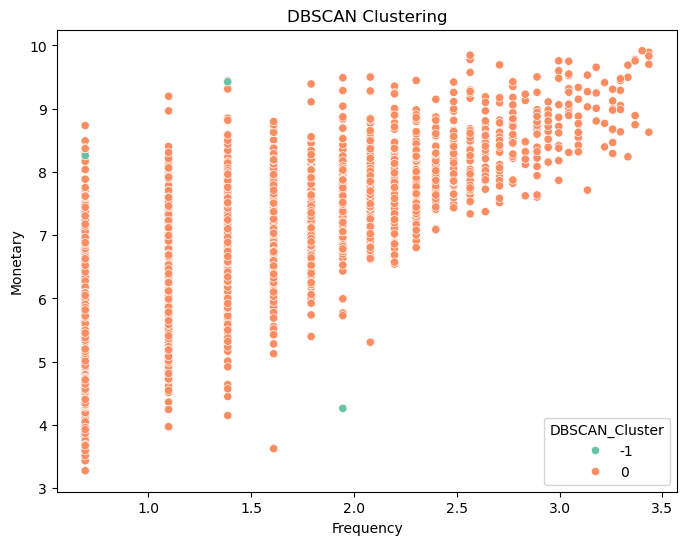

In [30]:
# Plot DBSCAN clusters
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=rfm_log['Frequency'],
    y=rfm_log['Monetary'],
    hue=rfm_log['DBSCAN_Cluster'],
    palette='Set2'
)

plt.title("DBSCAN Clustering")

plt.show()

In [32]:
# Business insights
# Average values of each cluster
cluster_profile = (
    rfm_log
    .groupby('Cluster')
    .mean()
)

print(cluster_profile)

          Recency  Frequency  Monetary  DBSCAN_Cluster
Cluster                                               
0        2.904406   0.995133  5.899390       -0.001192
1        2.296280   2.281526  8.050284       -0.001225
2        5.131311   0.804655  5.577058       -0.000698
3        4.062772   1.498778  7.141143        0.000000


In [ ]:
#Business Insights

The clusters created using K-Means represent different types of customers based on their purchasing behavior.

Cluster 0 — Loyal Customers
 Characteristics 
    Low Recency 
    High Frequency
    High Monetary value

These customers purchase frequently and spend more money. They are the most valuable customers for the business.

Business Strategy 
    1.Provide VIP membership 
    2.Offer loyalty rewards 
    3.Give early access to products 
    4.Send personalized recommendations 
                                                                                            
                                                                                               
Cluster 1 — Churn Risk Customers 
        Characteristics 
         High Recency 
         Low Frequency
         Low Monetary value

These customers have not purchased recently and may stop buying from the business.

Business Strategy 
1.Send discount coupons
2.Run re-engagement email campaigns 
3.Provide personalized offers
4.Use reminder notifications
Cluster 2 — Regular Customers
Characteristics
Medium Recency
Medium Frequency
Medium Monetary value

These customers purchase occasionally and generate moderate revenue.

Business Strategy 
1.Recommend related products 
2.Offer membership programs 
3.Use cross-selling techniques
4.Improve customer engagement 


Cluster 3 — Big Spenders 
Characteristics 
High Monetary value Frequent purchases

These customers contribute significantly to overall revenue.

Business Strategy 
1.Provide premium support 
2.Offer exclusive products
3.Create personalized marketing campaigns
4.Give premium discounts



In [33]:
rfm_log.to_csv(
    "customer_segments.csv"
)

In [34]:
rfm_log.to_csv(
    "customer_segments.csv"
)

print("File Saved Successfully")

File Saved Successfully


Conclusion

This project performed customer segmentation using the Online Retail dataset.

Data cleaning and preprocessing techniques were applied to remove missing values, cancelled orders, duplicates, and invalid transactions.

RFM (Recency, Frequency, Monetary) analysis was used to understand customer purchasing behavior.

K-Means clustering grouped customers into different segments such as:

Loyal Customers
Regular Customers
Big Spenders
Churn Risk Customers

PCA visualization helped visualize customer clusters in two dimensions.

DBSCAN clustering was also applied to identify noise and outlier customers.

The insights generated from this project can help businesses improve:

customer retention
personalized marketing
customer engagement
sales strategies